# Electricity tables: row counts by month/year

Pulls data from all EIA electricity ingest tables in Postgres and displays row counts by period (month/year) using Plotly.

In [1]:
import os
import pandas as pd
import plotly.express as px

from energy_usa.db import query_to_dataframe

url = os.environ["INGEST_DATABASE_URL"]

# All electricity ingest tables (have 'period' and row counts)
ELECTRICITY_TABLES = [
    "eia_retail_sales",
    "eia_electric_power_operational",
    "eia_state_source_disposition",
    "eia_state_summary",
]

In [2]:
def row_counts_by_period(conn_url: str, table: str) -> pd.DataFrame:
    """Return a DataFrame with columns period, row_count for the given table."""
    sql = f"""
    SELECT period, COUNT(*) AS row_count
    FROM {table}
    GROUP BY period
    ORDER BY period
    """
    df = query_to_dataframe(conn_url, sql)
    df["table_name"] = table
    return df


frames = []
for table in ELECTRICITY_TABLES:
    try:
        df = row_counts_by_period(url, table)
        frames.append(df)
    except Exception as e:
        print(f"Skip {table}: {e}")

combined = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if combined.empty:
    print("No data found. Ensure ingest has run and INGEST_DATABASE_URL is set.")
else:
    combined = combined.sort_values(["table_name", "period"])
combined

/app/src/energy_usa/db/dataframe.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,period,row_count,table_name
300,period,row_count,eia_electric_power_operational
301,period,row_count,eia_electric_power_operational
302,period,row_count,eia_electric_power_operational
303,period,row_count,eia_electric_power_operational
304,period,row_count,eia_electric_power_operational
...,...,...,...
358,period,row_count,eia_state_source_disposition
359,period,row_count,eia_state_summary
360,period,row_count,eia_state_summary
361,period,row_count,eia_state_summary


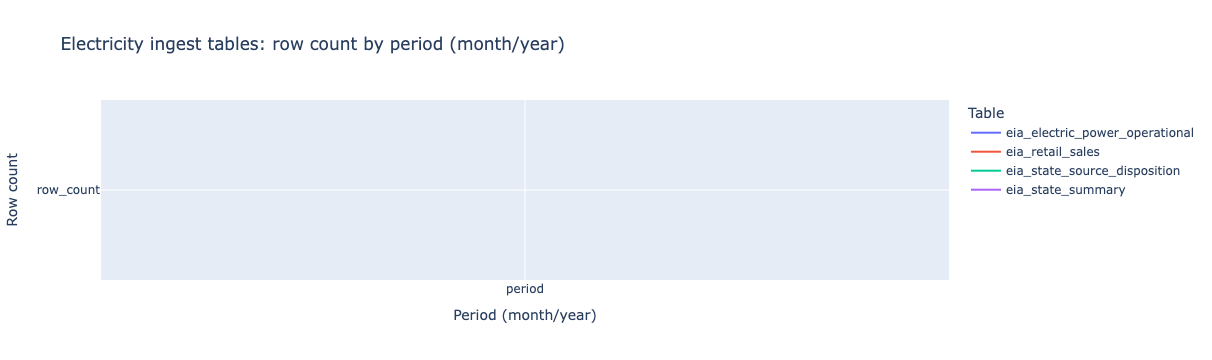

In [3]:
# Row counts by period (month/year) with Plotly
if not combined.empty:
    fig = px.line(
        combined,
        x="period",
        y="row_count",
        color="table_name",
        title="Electricity ingest tables: row count by period (month/year)",
        labels={"row_count": "Row count", "period": "Period", "table_name": "Table"},
    )
    fig.update_layout(
        xaxis_title="Period (month/year)",
        yaxis_title="Row count",
        legend_title="Table",
        hovermode="x unified",
    )
    fig.show()
else:
    print("No data to plot.")

In [ ]:
# Summary: total rows per table and by year
if not combined.empty:
    # Period is typically YYYY-MM; take first 4 chars for year
    combined["year"] = combined["period"].astype(str).str[:4].astype(int)
    summary = combined.groupby(["table_name", "year"], as_index=False).agg(
        row_count=("row_count", "sum")
    )
    pivot = summary.pivot(index="year", columns="table_name", values="row_count").fillna(0).astype(int)
    display(pivot)
    print("\nTotal rows per table:")
    display(combined.groupby("table_name")["row_count"].sum().to_frame(name="total_rows"))